# AR Question-Fold Evaluation

This notebook reads non-overlapping question-level CV-fold AR evaluation results. Each fold trains AR on the other folds and scores both train and held-out questions.


In [2]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np

RESULTS_DIR = Path('/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged/ar_split_eval_parallel/merged')
RESULTS_PATH = RESULTS_DIR / 'split_results.jsonl'
SUMMARY_PATH = RESULTS_DIR / 'summary.json'
RANDOM_SEED = 1
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

def load_jsonl(path: Path):
    rows=[]
    with path.open(encoding='utf-8') as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

assert RESULTS_PATH.exists(), f'missing results: {RESULTS_PATH}'
rows = load_jsonl(RESULTS_PATH)
print('Loaded rows:', len(rows))
if SUMMARY_PATH.exists():
    print(SUMMARY_PATH.read_text(encoding='utf-8'))


Loaded rows: 37275
{
  "input_dir": "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged/ar_split_eval_parallel",
  "output_dir": "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged/ar_split_eval_parallel/merged",
  "num_split_dirs": 5,
  "merged_rows": 37275,
  "source_summaries": [
    {
      "run_dir": "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged",
      "metrics_path": "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged/spectrum_parallel/merged/metrics.jsonl",
      "output_dir": "/workspace/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged/ar_split_eval_parallel/split_00",
      "mixed_questions_total": 233,
      "n_splits": 5,
      "split_offset": 0,
      "use_reasoning_span": true,
      "config": {
        "run_dir": "/network/scratch/p/pingsheng.li/Learning_from_Retrospection/outputs/offline_math500_temp1_k32/qwen_qwen3_4b_limit500/merged",
        "metrics_p

In [3]:
metric_specs = [
    ('response_length', 'Response length'),
    ('analysis_length', 'Analysis length'),
    ('decay_rate', 'Power-law spectrum decay exponent'),
    ('ar_error', 'AR mean next-step error'),
]

def summarize(values):
    arr = np.asarray(values, dtype=np.float64)
    return {
        'n': int(arr.size),
        'mean': float(arr.mean()) if arr.size else None,
        'std': float(arr.std()) if arr.size else None,
        'min': float(arr.min()) if arr.size else None,
        'max': float(arr.max()) if arr.size else None,
    }

def compute_partition_gap_rows(rows, partition):
    filtered = [r for r in rows if r['partition'] == partition]
    by_fold = {}
    for r in filtered:
        by_fold.setdefault(int(r['fold_index']), []).append(r)
    out = []
    for fold_idx, fold_rows in sorted(by_fold.items()):
        by_question = {}
        for r in fold_rows:
            by_question.setdefault(r['question_uid'], []).append(r)
        for key, label in metric_specs:
            vals = []
            for qid, group in by_question.items():
                succ = [x for x in group if x['success']]
                fail = [x for x in group if not x['success']]
                if not succ or not fail:
                    continue
                succ_mean = float(np.mean([x[key] for x in succ]))
                fail_mean = float(np.mean([x[key] for x in fail]))
                vals.append(fail_mean - succ_mean)
            vals = np.asarray(vals, dtype=np.float64)
            out.append({
                'fold_index': fold_idx,
                'partition': partition,
                'metric': key,
                'label': label,
                'n_questions': int(vals.size),
                'mean_gap': float(vals.mean()) if vals.size else None,
                'median_gap': float(np.median(vals)) if vals.size else None,
                'positive': int(np.sum(vals > 0)),
                'negative': int(np.sum(vals < 0)),
                'zero': int(np.sum(vals == 0)),
                'values': vals.tolist(),
            })
    return out

train_gap_rows = compute_partition_gap_rows(rows, 'train')
heldout_gap_rows = compute_partition_gap_rows(rows, 'heldout')
print('Train fold rows:', len(train_gap_rows))
print('Held-out fold rows:', len(heldout_gap_rows))


Train fold rows: 20
Held-out fold rows: 20


In [5]:
for partition, gap_rows in [('train', train_gap_rows), ('heldout', heldout_gap_rows)]:
    print(f'PARTITION: {partition}')
    for key, label in metric_specs:
        vals = [r['mean_gap'] for r in gap_rows if r['metric'] == key and r['mean_gap'] is not None]
        print(label, summarize(vals))


PARTITION: train
Response length {'n': 5, 'mean': 118.12644095430589, 'std': 5.367608699601063, 'min': 111.56973090186625, 'max': 124.69297848759692}
Analysis length {'n': 5, 'mean': 118.12644095430589, 'std': 5.367608699601063, 'min': 111.56973090186625, 'max': 124.69297848759692}
Power-law spectrum decay exponent {'n': 5, 'mean': 0.006646323848931134, 'std': 0.0007128456632725692, 'min': 0.005893635174957634, 'max': 0.007569422409851751}
AR mean next-step error {'n': 5, 'mean': -0.0337688560945791, 'std': 0.0035169324659890455, 'min': -0.03827608478421822, 'max': -0.02830291014412012}
PARTITION: heldout
Response length {'n': 5, 'mean': 118.21709597622711, 'std': 21.3499373434762, 'min': 92.10993130015825, 'max': 144.04448557560298}
Analysis length {'n': 5, 'mean': 118.21709597622711, 'std': 21.3499373434762, 'min': 92.10993130015825, 'max': 144.04448557560298}
Power-law spectrum decay exponent {'n': 5, 'mean': 0.0066426456663927005, 'std': 0.0028504347139933295, 'min': 0.002994418940

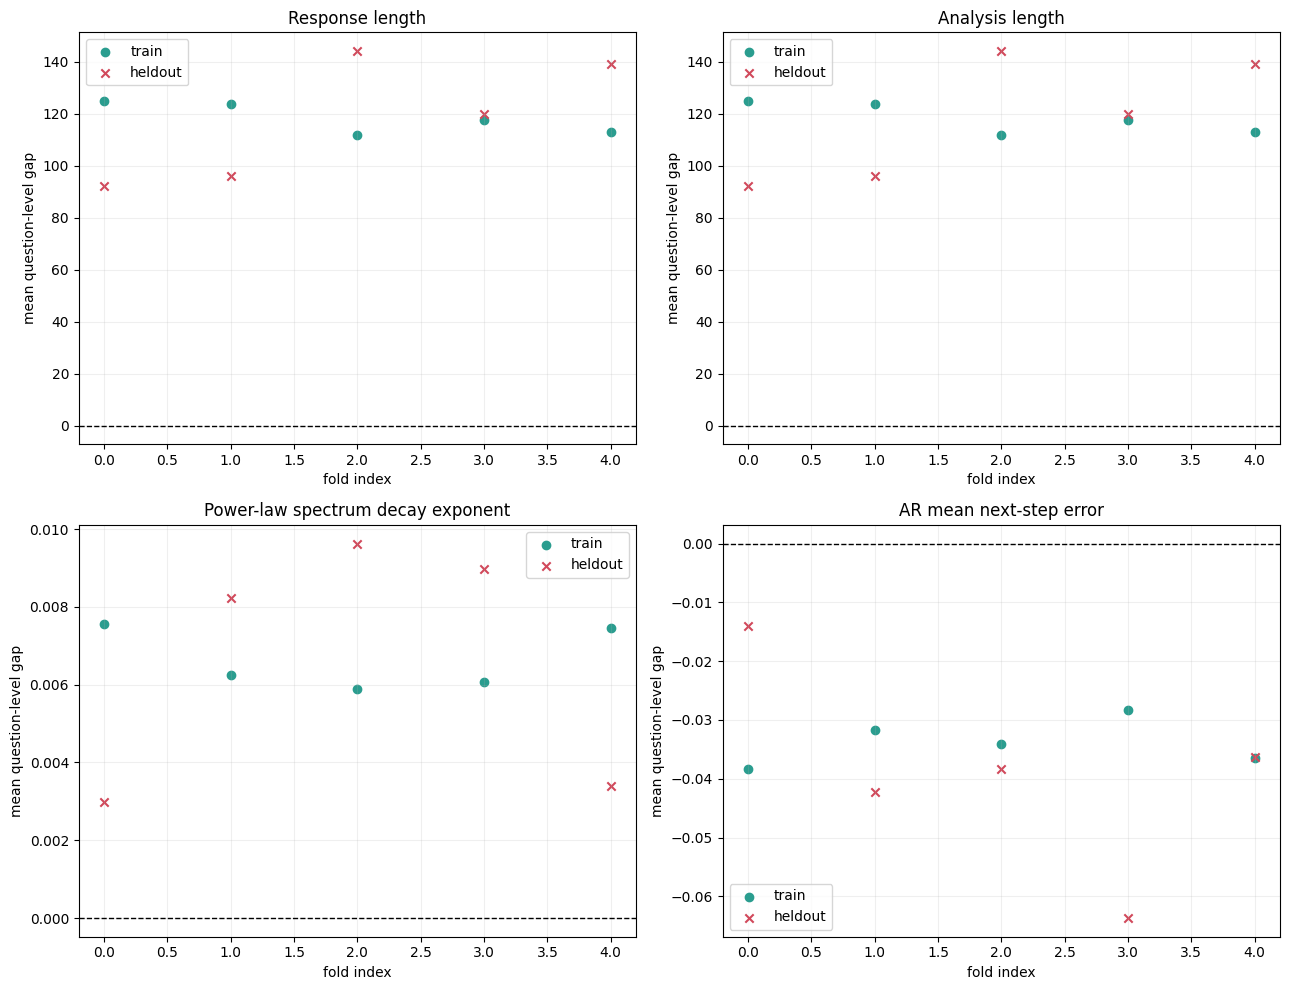

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()
for ax, (key, label) in zip(axes, metric_specs):
    train_vals = [r['mean_gap'] for r in train_gap_rows if r['metric'] == key and r['mean_gap'] is not None]
    held_vals = [r['mean_gap'] for r in heldout_gap_rows if r['metric'] == key and r['mean_gap'] is not None]
    ax.scatter(range(len(train_vals)), train_vals, label='train', color='#2a9d8f')
    ax.scatter(range(len(held_vals)), held_vals, label='heldout', color='#d1495b', marker='x')
    ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
    ax.set_title(label)
    ax.set_xlabel('fold index')
    ax.set_ylabel('mean question-level gap')
    ax.grid(alpha=0.2)
    ax.legend()
plt.tight_layout()
plt.show()


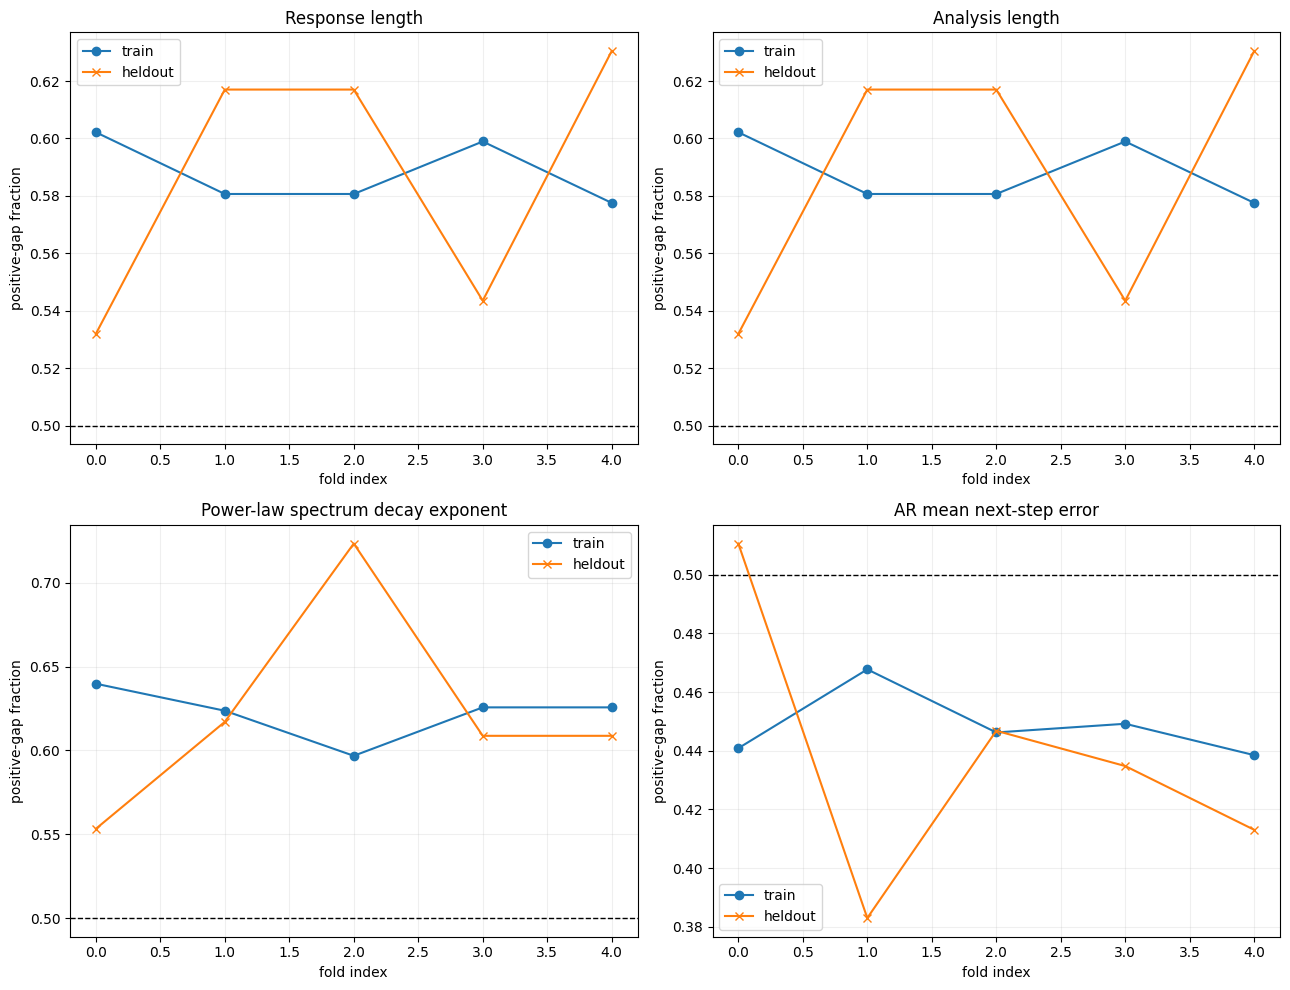

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.ravel()
for ax, (key, label) in zip(axes, metric_specs):
    train_pos = [r['positive'] / max(r['n_questions'], 1) for r in train_gap_rows if r['metric'] == key]
    held_pos = [r['positive'] / max(r['n_questions'], 1) for r in heldout_gap_rows if r['metric'] == key]
    ax.plot(train_pos, marker='o', label='train')
    ax.plot(held_pos, marker='x', label='heldout')
    ax.axhline(0.5, color='black', linestyle='--', linewidth=1)
    ax.set_title(label)
    ax.set_xlabel('fold index')
    ax.set_ylabel('positive-gap fraction')
    ax.grid(alpha=0.2)
    ax.legend()
plt.tight_layout()
plt.show()


In [9]:
def print_sign_summary(gap_rows, partition):
    print(f'PARTITION: {partition}')
    for key, label in metric_specs:
        rows_k = [r for r in gap_rows if r['metric'] == key]
        pos = [r['positive'] for r in rows_k]
        neg = [r['negative'] for r in rows_k]
        zero = [r['zero'] for r in rows_k]
        mean_gap = [r['mean_gap'] for r in rows_k if r['mean_gap'] is not None]
        print(label)
        print('  avg positive:', float(np.mean(pos)) if pos else None)
        print('  avg negative:', float(np.mean(neg)) if neg else None)
        print('  avg zero:', float(np.mean(zero)) if zero else None)
        print('  avg mean gap:', float(np.mean(mean_gap)) if mean_gap else None)

print_sign_summary(train_gap_rows, 'train')
print_sign_summary(heldout_gap_rows, 'heldout')


PARTITION: train
Response length
  avg positive: 109.6
  avg negative: 76.0
  avg zero: 0.8
  avg mean gap: 118.12644095430589
Analysis length
  avg positive: 109.6
  avg negative: 76.0
  avg zero: 0.8
  avg mean gap: 118.12644095430589
Power-law spectrum decay exponent
  avg positive: 116.0
  avg negative: 70.4
  avg zero: 0.0
  avg mean gap: 0.006646323848931134
AR mean next-step error
  avg positive: 83.6
  avg negative: 102.8
  avg zero: 0.0
  avg mean gap: -0.0337688560945791
PARTITION: heldout
Response length
  avg positive: 27.4
  avg negative: 19.0
  avg zero: 0.2
  avg mean gap: 118.21709597622711
Analysis length
  avg positive: 27.4
  avg negative: 19.0
  avg zero: 0.2
  avg mean gap: 118.21709597622711
Power-law spectrum decay exponent
  avg positive: 29.0
  avg negative: 17.6
  avg zero: 0.0
  avg mean gap: 0.0066426456663927005
AR mean next-step error
  avg positive: 20.4
  avg negative: 26.2
  avg zero: 0.0
  avg mean gap: -0.03893904088617967


In [10]:
# Pooled held-out view: every mixed-outcome question is evaluated out-of-sample exactly once.
heldout_rows = [r for r in rows if r['partition'] == 'heldout']
by_question = {}
for r in heldout_rows:
    by_question.setdefault(r['question_uid'], []).append(r)

for key, label in metric_specs:
    vals = []
    for qid, group in by_question.items():
        succ = [x for x in group if x['success']]
        fail = [x for x in group if not x['success']]
        if not succ or not fail:
            continue
        vals.append(float(np.mean([x[key] for x in fail]) - np.mean([x[key] for x in succ])))
    vals = np.asarray(vals, dtype=np.float64)
    print(label)
    print('  pooled held-out questions:', int(vals.size))
    print('  positive:', int(np.sum(vals > 0)))
    print('  negative:', int(np.sum(vals < 0)))
    print('  zero:', int(np.sum(vals == 0)))
    print('  mean gap:', float(vals.mean()) if vals.size else None)


Response length
  pooled held-out questions: 233
  positive: 137
  negative: 95
  zero: 1
  mean gap: 118.120432488414
Analysis length
  pooled held-out questions: 233
  positive: 137
  negative: 95
  zero: 1
  mean gap: 118.120432488414
Power-law spectrum decay exponent
  pooled held-out questions: 233
  positive: 145
  negative: 88
  zero: 0
  mean gap: 0.006646567632825924
AR mean next-step error
  pooled held-out questions: 233
  positive: 102
  negative: 131
  zero: 0
  mean gap: -0.03884400281733824
